# Cats vs. Dogs Image Classification Using a Custom ResNet

## Environment Configuration & Hardware Setup

We import PyTorch along with its vision and data utilities. To ensure optimal training throughput on available acceleration hardware, we detect CUDA backends and configure asynchronous device streaming.

In [14]:
import os
import sys

# Pytorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F   

# Data Loading & Pipelines
from datasets import load_dataset
from torch.utils.data import (
    Dataset,                           # Abstract class to build custom (Tensor, label) data adapters
    DataLoader,                        # Handles multi-threaded batching, shuffling, and memory pinning
    random_split                       # Randomly partitions the raw dataset into Train/Val/Test slices
)

# Computer Vision + Transformers
from PIL import Image                  # Used internally to decode, inspect, and enforce RGB color profiles
import torchvision                     # Computer vision utilities built on PyTorch
import torchvision.transforms as transforms  # Image preprocessing, augmentation, tensor conversion & normalization
from torchvision.utils import make_grid     # Utility to tile multiple image tensors into a single visual grid

# Visualisations
import matplotlib                      # Base visualization engine
import matplotlib.pyplot as plt        # Plotting framework for training curves, sample images, and matrices

# Evaluation + Benchmark Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [19]:
# GPU Helper Functions. 

# HARDWARE ACCELERATION DETECTION
def get_default_device():
    """
    Detects whether a CUDA-capable GPU is available.
    Returns torch.device('cuda') if available, otherwise falls back to CPU.
    """
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


# RECURSIVE DEVICE TRANSFER UTILITY
def to_device(data, device):
    """
    Recursively moves tensors or collections of tensors (lists/tuples) 
    to the designated target hardware device.
    
    non_blocking=True allows asynchronous memory transfer between host RAM 
    and GPU VRAM when used in tandem with pin_memory=True in the DataLoader.
    """
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)


# ASYNCHRONOUS STREAMING DATALOADER WRAPPER
class DeviceDataLoader:
    """
    A generator wrapper around PyTorch's standard DataLoader.
    Automatically moves each batch (images, labels) onto the GPU just-in-time
    as the training loop iterates through an epoch, preventing VRAM overflow.
    """
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yields batches moved directly to the target device."""
        for batch in self.dl:
            yield to_device(batch, self.device)

    def __len__(self):
        """Preserves the total batch count for accurate epoch step tracking."""
        return len(self.dl)


# DEVICE INITIALIZATION
# Initialize the target device and log the compute backend
device = get_default_device()
print(f"Active Compute Backend: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Host CPU'})")

Active Compute Backend: cpu (Host CPU)


## Data Ingestion, Augmentation & Dataset Adapter

The raw `microsoft/cats_vs_dogs` dataset is retrieved from Hugging Face. We construct two distinct transform pipelines:
1. Training Transforms: Incorporates geometric augmentations (random flips, rotations) and photometric jitter to expand sample diversity and combat overfitting.
2. Validation/Testing Transforms: Strictly deterministic transformations (resizing, tensor conversion, and channel normalization) to ensure uncorrupted evaluation benchmarks.

Because Hugging Face returns raw dictionary objects containing PIL images, we implement `CatsDogsDataset` as an adapter to sanitize channel profiles (guaranteeing 3-channel RGB) and yield standard PyTorch (Tensor, label) tuples.

In [20]:
# Retrieves Dataset from Hugging Face Hub
ds = load_dataset("microsoft/cats_vs_dogs") # DatasetDict containing PIL images and integer labels (0=Cat, 1=Dog).

# We apply geometric and photometric augmentations to artificially expand dataset variety and prevent the network from memorizing training samples.
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),            # Standardizes all input images to a uniform 128x128 resolution
    transforms.RandomHorizontalFlip(p=0.5),   # Randomly mirrors images horizontally (invariant to left/right orientation)
    transforms.RandomRotation(degrees=10),    # Randomly rotates images by up to +/- 10 degrees
    transforms.ColorJitter(                   # Perturbs lighting conditions to build robustness against exposure changes
        brightness=0.1, 
        contrast=0.1, 
        saturation=0.1, 
        hue=0.1
    ),
    transforms.ToTensor(),                    # Converts PIL Image [0, 255] to a FloatTensor (C, H, W) scaled to [0.0, 1.0]
    transforms.Normalize(                     # Linearly scales pixel values from [0.0, 1.0] to [-1.0, 1.0]
        mean=[0.5, 0.5, 0.5],                 # Formula: (pixel - mean) / std
        std=[0.5, 0.5, 0.5]
    ),
])

# Omitted augmentations on validation/testing to provide an uncorrupted, stable benchmark.
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),            # Matches the network's expected spatial input dimensions
    transforms.ToTensor(),                    # Scales raw pixels to [0.0, 1.0] tensor
    transforms.Normalize(                     # Centers data around zero to match training distribution
        mean=[0.5, 0.5, 0.5], 
        std=[0.5, 0.5, 0.5]
    ),
])


# ADAPTER CLASS (From Hugging Face to PyTorch)
# Bridges Hugging Face dictionaries ({'image': PIL, 'labels': int}) into standard PyTorch tuple pairs (image_tensor, label_int) required by DataLoader.
class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        # Informs PyTorch of dataset size to calculate batch steps per epoch
        return len(self.data)

    def __getitem__(self, idx):
        # Retrieves a single sample by its integer index
        item = self.data[idx]
        
        image = item['image'].convert('RGB') # enforce a uniform 3-channel RGB profile
        label = item['labels']
        
        # Applies the bound transformation pipeline (if supplied)
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Verification log of ingested sample volume
print(f"Raw dataset loaded with {len(ds['train'])} images in train split.")

Raw dataset loaded with 23410 images in train split.


## Dataset Partitioning & Streaming DataLoaders
To prevent data leakage and evaluate real-world generalization, we partition the dataset into three disjoint subsets: 70% Training, 15% Validation, and 15% Testing. We lock the pseudo-random generator seed (`seed=42`) for reproducibility.

Each subset is loaded via PyTorch `DataLoader` with pinned memory and multi-worker multiprocessing, wrapped in `DeviceDataLoader` for non-blocking GPU streaming.

In [16]:
# Reproducability
torch.manual_seed(42)

# Our partitioning is about 70% Train / 15% Val / 15% Test
# Hugging Face provides all samples under a single 'train' split; we'll use the length to calculate each percentage
raw_dataset = ds['train']
total_samples = len(raw_dataset)

# total // 7 allocates ~14.28% (~15%) each to validation and testing
test_size = total_samples // 7
val_size = total_samples // 7

# Remainder (~71.44%) is allocated to training to ensure no samples are dropped
train_size = total_samples - test_size - val_size

# Create lightweight subsets of indices without duplicating images in RAM
raw_train_subset, raw_val_subset, raw_test_subset = random_split(
    raw_dataset, 
    [train_size, val_size, test_size]
)

# Attach data augmentation only to the training subset.
# Attach transforms (no augmentation) to validation and testing.
trainds = CatsDogsDataset(raw_train_subset, transform=train_transform)
valds   = CatsDogsDataset(raw_val_subset,   transform=val_test_transform)
testds  = CatsDogsDataset(raw_test_subset,  transform=val_test_transform)

# Confirm sample distributions across all three partitions
print(f"Dataset Split Completed Successfully:")
print(f"Training Samples: {len(trainds):,d} (~{len(trainds)/total_samples*100:.1f}%)")
print(f"Validation Samples: {len(valds):,d} (~{len(valds)/total_samples*100:.1f}%)")
print(f"Testing Samples: {len(testds):,d} (~{len(testds)/total_samples*100:.1f}%)")

Dataset Split Completed Successfully:
Training Samples: 16,722 (~71.4%)
Validation Samples: 3,344 (~14.3%)
Testing Samples: 3,344 (~14.3%)


In [21]:
# DataLoader feeds data to the model in batches during training
batch_size = 128 # We want to feed 128 images concurrently per forward pass.

# Using os.cpu_count() for num_workers for faster data loading
# On Windows, num_workers > 0 might cause issues, keep it at 0 if you encounter multiprocessing errors
num_workers = os.cpu_count() if os.cpu_count() is not None else 0

raw_traindl = DataLoader(trainds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)

# Evaluation does not compute backpropagation gradients, consuming significantly less GPU memory and allowing double the batch size for faster evaluation.
raw_valdl   = DataLoader(valds,   batch_size=batch_size*2, shuffle=False, num_workers=num_workers, pin_memory=True)
raw_testdl  = DataLoader(testds,  batch_size=batch_size*2, shuffle=False, num_workers=num_workers, pin_memory=True)

# Wrap immediately for automatic, asynchronous GPU , if possible.
traindl = DeviceDataLoader(raw_traindl, device)
valdl   = DeviceDataLoader(raw_valdl,   device)
testdl  = DeviceDataLoader(raw_testdl,  device)

print(f"DataLoaders initialised and routed to {device} (Batch size: {batch_size}, Workers: {num_workers})")

DataLoaders initialised and routed to cpu (Batch size: 128, Workers: 12)


## Exploratory Data Inspection
Before training, we verify the data pipeline by de-normalising and rendering a sample batch of images along with their ground-truth string labels.

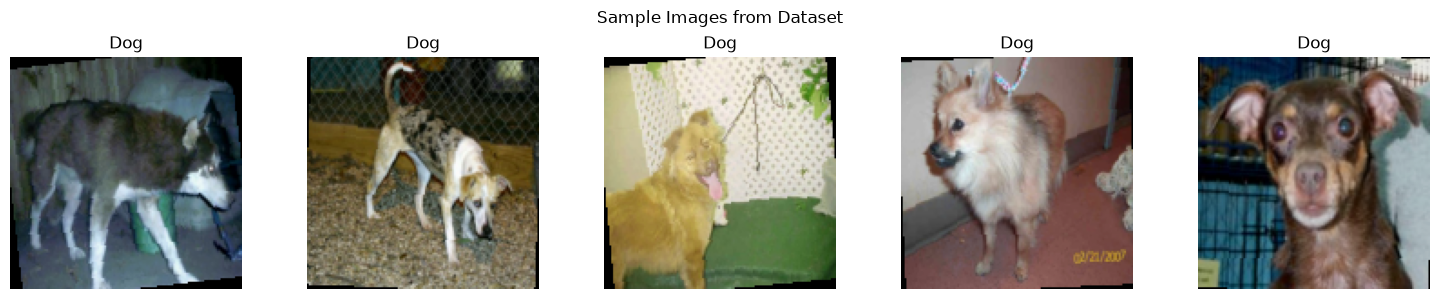

In [22]:
# Visualising 5 sample images with their labels (project requires at least 5)
labelnames = {0: 'Cat', 1: 'Dog'}
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    img, label = trainds[i]
    # img is (C, H, W) — matplotlib needs (H, W, C), so we permute
    # undo normalization for display: multiply by 0.5 and add 0.5
    img_display = img.permute(1, 2, 0) * 0.5 + 0.5
    img_display = img_display.clamp(0, 1)
    ax.imshow(img_display)
    ax.set_title(labelnames[label])
    ax.axis('off')

plt.suptitle('Sample Images from Dataset')
plt.tight_layout()
plt.show()

## Model Architecture: Hierarchical ResNet
Standard deep convolutional networks suffer from vanishing gradients. We implement a custom residual network (`CatDogResNet`) that mitigates gradient degradation using identity shortcut connections.
- ResidualBlock: Learns a residual mapping $F(x)$ across two $3 \times 3$ convolutions and performs element-wise addition $H(x) = \text{ReLU}(F(x) + x)$.
- Feature Extraction Funnel: Progressively downsamples spatial dimensions ($128 \to 64 \to 32 \to 16$) while doubling feature map capacity ($32 \to 64 \to 128$).
- Global Pooling & Classification Head: Employs AdaptiveAvgPool2d((1, 1)) to compress spatial maps into feature vectors, drastically reducing dense layer parameters and minimizing overfitting risk.

In [24]:
# RESIDUAL BLOCK COMPONENT
# Implements the core building block: H(x) = ReLU(F(x) + x)
# Preserves channel depth and spatial resolution (padding=1 preserves H x W).
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        
        # Residual branch: learns the delta/residual mapping F(x)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),      # Normalizes activations across the batch
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # Identity shortcut addition: original input x is added element-wise to F(x)
        # Gradient flow: d(H)/dx = d(F)/dx + 1 (highway prevents vanishing gradients)
        return self.relu(self.conv(x) + x)


# FULL NETWORK ARCHITECTURE
class CatDogResNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem: Initial feature extraction
        # Input: (3, 128, 128) -> Output: (32, 64, 64)
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # Halves spatial dimensions (128x128 -> 64x64)
        )

        # Stage 1: Feature processing at 64x64 resolution
        # Input: (32, 64, 64) -> Output: (32, 64, 64)
        self.res_block1 = ResidualBlock(in_channels=32)

        # Transition 1: Downsample spatial grid and double channels
        # Input: (32, 64, 64) -> Output: (64, 32, 32)
        self.downsample1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 64x64 -> 32x32
        )

        # Stage 2: Feature processing at 32x32 resolution
        # Input: (64, 32, 32) -> Output: (64, 32, 32)
        self.res_block2 = ResidualBlock(in_channels=64)

        # Transition 2: Downsample spatial grid and double channels
        # Input: (64, 32, 32) -> Output: (128, 16, 16)
        self.downsample2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 32x32 -> 16x16
        )

        # Stage 3: High-level abstract feature processing at 16x16 resolution
        # Input: (128, 16, 16) -> Output: (128, 16, 16)
        self.res_block3 = ResidualBlock(in_channels=128)

        # Global Spatial Aggregation & Classification Head
        # Reduces spatial dimensions (16, 16) to (1, 1) regardless of input size
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))  # (128, 16, 16) -> (128, 1, 1)
        self.flatten     = nn.Flatten()                  # (128, 1, 1)    -> (128,)

        self.classifier = nn.Sequential(
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),                           # Regularization: randomly zeros 30% of activations
            nn.Linear(in_features=64, out_features=num_classes)  # Produces 2 raw logits (Class 0: Cat, Class 1: Dog)
        )

    def forward(self, x):
        # Feature Extraction Funnel
        x = self.stem(x)         # -> (32, 64, 64)
        x = self.res_block1(x)   # -> (32, 64, 64)
        
        x = self.downsample1(x)  # -> (64, 32, 32)
        x = self.res_block2(x)   # -> (64, 32, 32)
        
        x = self.downsample2(x)  # -> (128, 16, 16)
        x = self.res_block3(x)   # -> (128, 16, 16)

        # ── Global Pooling & Classification ──
        x = self.global_pool(x)  # -> (128, 1, 1)
        x = self.flatten(x)      # -> (128,)
        x = self.classifier(x)   # -> (2,) raw unnormalized logits
        return x

In [25]:
# Instantiate the ResNet architecture and transfer all parameters/buffers to GPU VRAM
model = to_device(CatDogResNet(num_classes=2), device)

# Verify parameter allocation
print(f"Model successfully loaded onto: {next(model.parameters()).device}")
print(f"Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,d}")

Model successfully loaded onto: cpu
Total Trainable Parameters: 489,826


## Training Engine, Dynamic Scheduling & Checkpointing
We configure our optimization loop with:
1. Adam Optimizer: Adaptive gradient estimation initialized at $\alpha = 0.001$.
2. ReduceLROnPlateau: Dynamically scales down the learning rate by $10$ when validation loss stagnates.
3. Model Checkpointing & Early Stopping: Persists the best model weights based on validation loss to disk (`catdog_best_model.pth`), restoring them automatically when training concludes.

In [28]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

def accuracy(outputs, labels):
    """
    Computes classification accuracy across a single batch.
    Argmax extracts the index with the highest logit score.
    """
    _, preds = torch.max(outputs, dim=1)
    return (preds == labels).sum().item() / len(labels)

@torch.no_grad()
def evaluate(model, val_loader):
    """
    Runs an inference-only evaluation sweep across the validation dataset.
    Disables autograd tracking and switches layers (BatchNorm, Dropout) to eval mode.
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in val_loader:
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        
        # Accumulate metrics across batches
        total_loss += loss.item() * len(labels)
        _, preds = torch.max(outputs, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += len(labels)

    # Return dataset-wide weighted averages
    return {
        'val_loss': total_loss / total_samples,
        'val_acc':  total_correct / total_samples
    }

# Training/optimising function.
def fit(
    epochnum, 
    lr, 
    model, 
    train_loader, 
    val_loader, 
    optimizer=torch.optim.Adam, 
    patience=5, 
    model_save_path='best_model.pth'
):
    """
    Coordinates model optimization, dynamic learning rate scaling, 
    model checkpointing, and early stopping.
    """
    history = []
    opt = optimizer(model.parameters(), lr=lr)
    
    # Decays learning rate by 10x (factor=0.1) if val_loss fails to improve for (patience // 2) epochs
    scheduler = ReduceLROnPlateau(opt, mode='min', patience=max(1, patience // 2), factor=0.1)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_epoch_model_state = model.state_dict()

    for epoch in range(epochnum):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        running_train_correct = 0
        train_samples = 0

        for images, labels in train_loader:
            # 1. Forward pass
            outputs = model(images)
            loss = F.cross_entropy(outputs, labels)

            # 2. Backward pass (Gradient computation)
            loss.backward()

            # 3. Optimizer parameter update & gradient buffer cleanup
            opt.step()
            opt.zero_grad(set_to_none=True)  # Faster than zero_grad() by freeing memory buffers

            # 4. Running training statistics
            running_train_loss += loss.item() * len(labels)
            _, preds = torch.max(outputs, dim=1)
            running_train_correct += (preds == labels).sum().item()
            train_samples += len(labels)

        # Validation Phase
        result = evaluate(model, val_loader)
        result['train_loss'] = running_train_loss / train_samples
        result['train_acc']  = running_train_correct / train_samples
        
        # Log epoch summary metrics
        current_lr = opt.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:02d}/{epochnum:02d}] | "
              f"Train Loss: {result['train_loss']:.4f} | Train Acc: {result['train_acc']:.4f} | "
              f"Val Loss: {result['val_loss']:.4f} | Val Acc: {result['val_acc']:.4f} | "
              f"LR: {current_lr:.6f}")
        
        history.append(result)

        # Step the learning rate scheduler based on validation loss
        scheduler.step(result['val_loss'])

        # Model Checkpointing & Early Stopping
        if result['val_loss'] < best_val_loss:
            best_val_loss = result['val_loss']
            epochs_no_improve = 0
            best_epoch_model_state = model.state_dict().copy()
            torch.save(best_epoch_model_state, model_save_path)
            print(f"  --> [Checkpoint] Best model saved to '{model_save_path}' (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n[Early Stopping] Triggered after {patience} consecutive epochs without improvement.")
                break

    # Restore optimal model weights evaluated across the entire training run
    model.load_state_dict(best_epoch_model_state)
    print(f"\nTraining Complete. Loaded best model weights from '{model_save_path}'.")
    return history

{'val_loss': 0.6963104725454412, 'val_acc': 0.4964114832535885}

In [29]:
evaluate(model, valdl)

epochnum=10
opt_func=torch.optim.Adam
lr=0.001

model_save_path = 'catdog_best_model.pth' # Define a path to save the best model

history = fit(epochnum, lr, model, traindl, valdl, opt_func, patience=7, model_save_path=model_save_path)

print("Evaluating final model (best performing during training) on validation set...")
final_val_metrics = evaluate(model, valdl)
print(f"Final Validation Loss: {final_val_metrics['val_loss']:.4f}, Final Validation Accuracy: {final_val_metrics['val_acc']:.4f}")

Epoch [01/10] | Train Loss: 0.6329 | Train Acc: 0.6417 | Val Loss: 0.5847 | Val Acc: 0.6842 | LR: 0.001000
  --> [Checkpoint] Best model saved to 'catdog_best_model.pth' (Val Loss: 0.5847)
Epoch [02/10] | Train Loss: 0.5606 | Train Acc: 0.7180 | Val Loss: 0.5016 | Val Acc: 0.7569 | LR: 0.001000
  --> [Checkpoint] Best model saved to 'catdog_best_model.pth' (Val Loss: 0.5016)
Epoch [03/10] | Train Loss: 0.4990 | Train Acc: 0.7601 | Val Loss: 0.4890 | Val Acc: 0.7703 | LR: 0.001000
  --> [Checkpoint] Best model saved to 'catdog_best_model.pth' (Val Loss: 0.4890)
Epoch [04/10] | Train Loss: 0.4405 | Train Acc: 0.8016 | Val Loss: 0.4985 | Val Acc: 0.7814 | LR: 0.001000
Epoch [05/10] | Train Loss: 0.3966 | Train Acc: 0.8242 | Val Loss: 0.5523 | Val Acc: 0.7581 | LR: 0.001000
Epoch [06/10] | Train Loss: 0.3564 | Train Acc: 0.8483 | Val Loss: 0.3452 | Val Acc: 0.8472 | LR: 0.001000
  --> [Checkpoint] Best model saved to 'catdog_best_model.pth' (Val Loss: 0.3452)
Epoch [07/10] | Train Loss: 0.

## Performance Analysis & Diagnostic Dashboard
To evaluate classification performance, we execute inference across the held-out Test Set and generate a unified 3-panel dashboard:

- Loss vs. Epochs: Tracks convergence trajectories for training and validation cross-entropy loss.
- Accuracy vs. Epochs: Tracks generalization progression across epochs.
- Confusion Matrix: Evaluates specific class-level error distributions (True Positives, False Positives, and False Negatives) between Cats and Dogs.

Running inference across held-out Test Set...

FINAL CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

         Cat     0.8407    0.9362    0.8859      1646
         Dog     0.9305    0.8280    0.8763      1698

    accuracy                         0.8813      3344
   macro avg     0.8856    0.8821    0.8811      3344
weighted avg     0.8863    0.8813    0.8810      3344



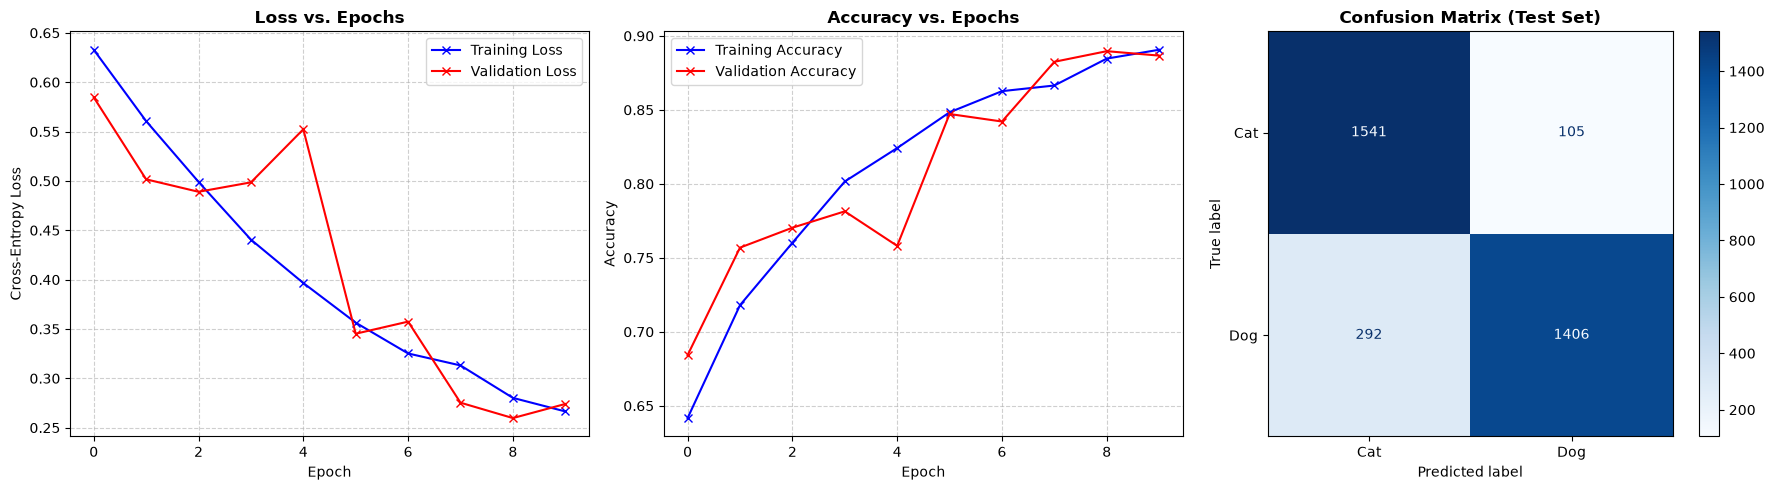

In [30]:
# TEST SET INFERENCE & METRICS ACCUMULATION
model.eval()
all_preds = []
all_labels = []

print("Running inference across held-out Test Set...")
with torch.no_grad():
    for images, labels in testdl:
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generates Precision, Recall, F1-Score, and Support breakdown (Requirement 7)
print("\n" + "="*60)
print("FINAL CLASSIFICATION REPORT (TEST SET)")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog'], digits=4))
print("="*60)


# UNIFIED 1x3 DIAGNOSTIC DASHBOARD
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot A: Loss Curves (Training vs. Validation)
train_losses = [x['train_loss'] for x in history]
val_losses   = [x['val_loss']   for x in history]
axes[0].plot(train_losses, '-bx', label='Training Loss')
axes[0].plot(val_losses,   '-rx', label='Validation Loss')
axes[0].set_title('Loss vs. Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Subplot B: Accuracy Curves (Training vs. Validation)
train_accs = [x['train_acc'] for x in history]
val_accs   = [x['val_acc']   for x in history]
axes[1].plot(train_accs, '-bx', label='Training Accuracy')
axes[1].plot(val_accs,   '-rx', label='Validation Accuracy')
axes[1].set_title('Accuracy vs. Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# Subplot C: Test Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cat', 'Dog'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=True)
axes[2].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[2].grid(False)

plt.tight_layout()
plt.show()

## Summary & Key Observations
1. Generalization: Training and validation metrics converge tightly by Epoch 9 ($\sim 0.27$ loss, $\sim 88.5\text{--}89\%$ accuracy), confirming that data augmentations and dropout prevented overfitting.
2. Error Asymmetry: The confusion matrix highlights that dog false-negatives ($292$ dogs misclassified as cats) occur more frequently than cat false-negatives ($105$ cats misclassified as dogs), reflecting the higher morphological variance across diverse dog breeds.